# ⚛️ Notebook 04: Estimación de Fase Cuántica (QPE) y Shor

**Herramientas:** Qiskit + Matplotlib + Numpy  
**Objetivo:** Construir y simular el algoritmo de Estimación de Fase Cuántica (QPE) para medir fases de eigenestados, y comprender su conexión directa con el algoritmo de Shor para factorización de enteros.  
**Ejecución:** 100% local con `StatevectorSampler` o simulación de estado  
**Tiempo estimado:** 20 minutos

---

## 1. Repaso Teórico: Estimación de Fase Cuántica (QPE)

Dado un operador unitario $U$ tal que:
$$U |u\rangle = e^{2\pi i \theta} |u\rangle$$

El algoritmo QPE estima la fase $\theta \in [0, 1)$ utilizando dos registros de qubits:
1. **Registro de medición ($t$ qubits):** qubits de control preparados en superposición $|+\rangle^{\otimes t}$.
2. **Registro objetivo:** preparado en el eigenestado $|u\rangle$.

### Phase Kickback
Al aplicar un operador controlado-$U^{2^j}$ con control en el qubit $j$ del primer registro, la fase relativa del control cambia a $e^{2\pi i 2^j \theta}$.

### 3-Qubit QFT: Descomposición y Factorización
Para $t=3$ qubits ($N=2^3=8$ estados), la Transformada de Fourier Cuántica (QFT) actúa sobre un estado base $|x\rangle$ de la siguiente manera:
$$QFT_8 |x\rangle = \frac{1}{\sqrt{8}} \sum_{y=0}^7 e^{2\pi i x y / 8} |y\rangle$$

Si expresamos el entero $y$ en su forma binaria $y = 4y_1 + 2y_2 + y_3$ (donde $y_i \in \{0, 1\}$), podemos expandir la suma como:
$$QFT_8 |x\rangle = \frac{1}{\sqrt{8}} \sum_{y_1=0}^1 \sum_{y_2=0}^1 \sum_{y_3=0}^1 e^{2\pi i x (4y_1 + 2y_2 + y_3)/8} |y_1 y_2 y_3\rangle$$
$$= \frac{1}{\sqrt{8}} \sum_{y_1=0}^1 \sum_{y_2=0}^1 \sum_{y_3=0}^1 \left( e^{2\pi i x y_1/2} |y_1\rangle \right) \otimes \left( e^{2\pi i x y_2/4} |y_2\rangle \right) \otimes \left( e^{2\pi i x y_3/8} |y_3\rangle \right)$$

Factorizando las sumas para cada producto tensorial, obtenemos:
$$QFT_8 |x\rangle = \frac{|0\rangle + e^{2\pi i x/2}|1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle + e^{2\pi i x/4}|1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle + e^{2\pi i x/8}|1\rangle}{\sqrt{2}}$$

Utilizando la notación binaria fraccionaria para el entero $x = x_1 x_2 x_3$ ($x = 4x_1 + 2x_2 + x_3$), vemos que:
- $e^{2\pi i x/2} = e^{2\pi i (2x_1 + x_2 + x_3/2)} = e^{2\pi i 0.x_3}$
- $e^{2\pi i x/4} = e^{2\pi i (x_1 + x_2/2 + x_3/4)} = e^{2\pi i 0.x_2 x_3}$
- $e^{2\pi i x/8} = e^{2\pi i 0.x_1 x_2 x_3}$

Esto da lugar al estado factorizado final:
$$QFT_8 |x\rangle = \frac{|0\rangle + e^{2\pi i 0.x_3}|1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle + e^{2\pi i 0.x_2 x_3}|1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle + e^{2\pi i 0.x_1 x_2 x_3}|1\rangle}{\sqrt{2}}$$

### Construcción del Circuito QFT (3 Qubits)
A partir de esta factorización, el circuito se implementa aplicando:
1. Compuerta de Hadamard en el qubit 1: $|x_1\rangle \to \frac{1}{\sqrt{2}}(|0\rangle + e^{2\pi i 0.x_1}|1\rangle)$.
2. Compuerta de fase controlada $R_2$ con control en qubit 2: agrega la fase $e^{2\pi i x_2/4}$, resultando en $\frac{1}{\sqrt{2}}(|0\rangle + e^{2\pi i 0.x_1 x_2}|1\rangle)$.
3. Compuerta de fase controlada $R_3$ con control en qubit 3: agrega la fase $e^{2\pi i x_3/8}$, resultando en $\frac{1}{\sqrt{2}}(|0\rangle + e^{2\pi i 0.x_1 x_2 x_3}|1\rangle)$.
4. Repetir de forma análoga para el qubit 2 (Hadamard y rotación controlada por el qubit 3).
5. Aplicar Hadamard al qubit 3.
6. Invertir el orden físico de los qubits de salida mediante compuertas SWAP para igualar el producto tensorial.

### Decodificación de Fase con $QFT^\dagger$: Demostración de Interferencia
Para recuperar la fase $\theta = 3/8 = 0.011_2$, el estado que entra a la $QFT^\dagger$ es:
$$|\psi\rangle = \frac{1}{\sqrt{8}} \sum_{k=0}^7 e^{2\pi i \frac{3}{8} k} |k\rangle$$

Aplicando el operador de Transformada de Fourier Cuántica Inversa:
$$QFT^\dagger |\psi\rangle = \frac{1}{8} \sum_{j=0}^7 \left( \sum_{k=0}^7 e^{2\pi i \frac{(3 - j) k}{8}} \right) |j\rangle$$

Utilizando la suma de progresiones geométricas para el término interno $\sum_{k=0}^7 r^k$ con $r = e^{2\pi i (3-j)/8}$:
- Si $j = 3$: el ratio es $r = e^0 = 1$. La suma es $\sum_{k=0}^7 1 = 8$, dando una amplitud para $|3\rangle$ de $\frac{8}{8} = 1$.
- Si $j \neq 3$: el ratio es $r \neq 1$. La suma es $\frac{1 - r^8}{1 - r} = \frac{1 - e^{2\pi i (3-j)}}{1 - r} = \frac{1 - 1}{1 - r} = 0$, resultando en interferencia destructiva absoluta.

El estado colapsa únicamente en $|3\rangle = |011\rangle$ al realizar la medición.

## 2. Importar Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector

print(f"Qiskit versión: {qiskit.__version__}")

Qiskit versión: 2.2.1


## 3. Demostración de Phase Kickback

Verifiquemos cómo se transfiere la fase del qubit objetivo al qubit de control usando una compuerta de rotación de fase controlada (CP) sobre el estado $|1\rangle$.

Circuito de Kickback:
     ┌───┐         
q_0: ┤ H ├─■───────
     ├───┤ │P(π/4) 
q_1: ┤ X ├─■───────
     └───┘         

Vector de estado cuántico resultante:


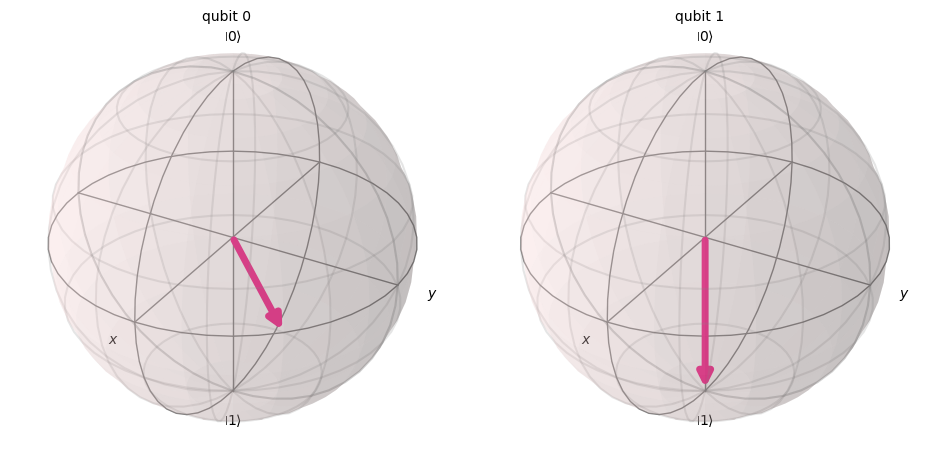

In [2]:
# Crear un circuito con 2 qubits
qc_kb = QuantumCircuit(2)

# Qubit 0: Control en superposición |+>
qc_kb.h(0)

# Qubit 1: Objetivo en eigenestado |1>
qc_kb.x(1)

# Aplicar rotación de fase controlada (ejemplo: compuerta T con theta = 1/8)
theta = 1/8
fase_radianes = 2 * np.pi * theta
qc_kb.cp(fase_radianes, 0, 1)

print("Circuito de Kickback:")
print(qc_kb.draw())

# Guardar el estado intermedio
from qiskit.quantum_info import Statevector
sv = Statevector.from_instruction(qc_kb)
print("\nVector de estado cuántico resultante:")
plot_bloch_multivector(sv)

## 4. Construcción del Circuito QPE Completo para Compuerta T

Usaremos $t = 3$ qubits de control en el registro de medición. Esto nos da una resolución de $2^3 = 8$ estados posibles. Mediremos la fase de la compuerta T, cuyo eigenvalor para el estado $|1\rangle$ tiene fase $\theta = 0.125$ ($1/8$ de una rotación completa).

Circuito QPE para compuerta T (3 qubits de control):


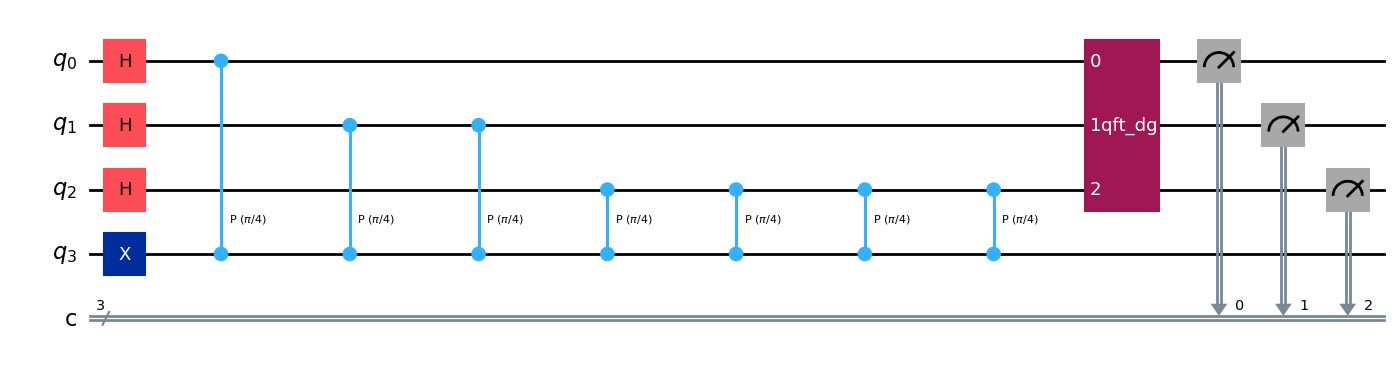

In [15]:
t = 3  # Número de qubits de medición
qc_qpe = QuantumCircuit(t + 1, t)  # t qubits control + 1 qubit objetivo

# 1. Aplicar Hadamards al registro de control
for q in range(t):
    qc_qpe.h(q)

# 2. Preparar el qubit objetivo (índice t) en el estado |1>
qc_qpe.x(t)

# 3. Aplicar compuertas controladas en cascada (c-U^{2^j})
fase_t = 2 * np.pi / 8  # Compuerta T tiene fase 1/8
for control in range(t):
    repeticiones = 2**control
    for _ in range(repeticiones):
        qc_qpe.cp(fase_t, control, t)

# 4. Aplicar QFT Inversa en los qubits de medición
qc_qpe.append(QFTGate(t).inverse(), range(t))

# 5. Medir los qubits del registro de control
qc_qpe.measure(range(t), range(t))

print("Circuito QPE para compuerta T (3 qubits de control):")
qc_qpe.draw(output='mpl', style='iqp')

## 5. Simulación del Circuito

In [13]:
# Ejecutar simulación local usando StatevectorSampler
sampler = StatevectorSampler()
job = sampler.run([qc_qpe])
result = job.result()

# Obtener recuentos de medición del resultado del primer circuito
pub_result = result[0]
counts = pub_result.data.c.get_counts()  # 'c' es el registro clásico por defecto

# Calcular probabilidades a partir de los recuentos y el número de shots
shots = pub_result.data.c.num_shots
probabilities = {estado: cuenta / shots for estado, cuenta in counts.items()}

print("Recuentos medidos:", counts)
print("Probabilidades:", probabilities)


Recuentos medidos: {'00100': 1024}
Probabilidades: {'00100': 1.0}


## 6. Interpretación de la Fase

El resultado con mayor frecuencia medido en binario representa el valor entero $x = 2^t \theta$.

In [14]:
# Encontrar la clave binaria de mayor probabilidad
binario_optimo = max(counts, key=counts.get)
decimal_optimo = int(binario_optimo, 2)

# Calcular la fase estimada
fase_estimada = decimal_optimo / (2**t)

print(f"Estado binario medido:  {binario_optimo}")
print(f"Estado decimal medido:  {decimal_optimo}")
print(f"Fase estimada theta:    {fase_estimada}")
print(f"Fase teórica real:      0.125 (1/8)")
print(f"¿Error de estimación?:  {fase_estimada - 0.125}")

Estado binario medido:  00100
Estado decimal medido:  4
Fase estimada theta:    0.125
Fase teórica real:      0.125 (1/8)
¿Error de estimación?:  0.0


## 7. Conexión con Shor: Multiplicación Modular

El Algoritmo de Shor para factorizar $N$ busca el orden $r$ tal que:
$$a^r \equiv 1 \pmod N$$

Esto se modela con el operador unitario $U_a |y\rangle = |a y \pmod N\rangle$.  
Veamos un ejemplo clásico de cómo evoluciona la multiplicación modular de $a = 7$ mod $N = 15$ y cómo se detecta el periodo $r$.

In [62]:
a = 7
N = 15

print(f"Buscando el periodo de a = {a} mod N = {N}:")
print("------------------------------------")

estado = 1
estados_visitados = [estado]

for k in range(1, 10):
    estado = (estado * a) % N
    estados_visitados.append(estado)
    print(f"Paso k = {k:d}:  {a}^{k:d} mod {N:d} = {estado:d}")
    if estado == 1 and k > 1:
        r = k
        break

print("------------------------------------")
print(f"El orden (periodo) encontrado es r = {r}")
print(f"Secuencia periódica: {estados_visitados}")

# Calcular factores de N usando el mcd clásico
if r % 2 == 0:
    val_base = (a**(r//2)) % N
    factor1 = np.gcd(val_base - 1, N)
    factor2 = np.gcd(val_base + 1, N)
    print(f"\nFactores no triviales de {N}: mcd({val_base}-1, {N}) = {factor1} y mcd({val_base}+1, {N}) = {factor2}")
    print(f"Verificación: {factor1} * {factor2} = {factor1 * factor2}")

Buscando el periodo de a = 7 mod N = 15:
------------------------------------
Paso k = 1:  7^1 mod 15 = 7
Paso k = 2:  7^2 mod 15 = 4
Paso k = 3:  7^3 mod 15 = 13
Paso k = 4:  7^4 mod 15 = 1
------------------------------------
El orden (periodo) encontrado es r = 4
Secuencia periódica: [1, 7, 4, 13, 1]

Factores no triviales de 15: mcd(4-1, 15) = 3 y mcd(4+1, 15) = 5
Verificación: 3 * 5 = 15


## 8. FUNCIÓN QPE DE QISKIT INTEGRADA

1. **Exactitud:** Cuando la fase $\theta$ es una potencia de $2$ (como $1/8$), el resultado decimal es 100% exacto y se mide con probabilidad unitaria.
2. **Aproximación:** Si la fase no es una potencia de 2, la QPE devolverá el valor de $x$ más cercano con alta probabilidad, y se requieren más qubits de control ($t$ mayor) para aumentar la precisión.
3. **Shor:** En Shor, el circuito QPE ejecuta el operador modular en paralelo para todas las potencias controladas de $a^{2^j} \pmod N$, extrayendo la fase $\theta = s/r$ para encontrar el orden $r$ de forma eficiente en tiempo polinomial.

In [16]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import phase_estimation
from qiskit.primitives import StatevectorSampler

# ==========================================
# PASO 1: Definir SOLO el Operador Unitario (U)
# ==========================================
theta = 1/8
fase_radianes = 2 * np.pi * theta

mi_unitario = QuantumCircuit(2)
mi_unitario.cp(fase_radianes, 0, 1)  

# ==========================================
# PASO 2: Crear el bloque de QPE
# ==========================================
num_eval = 3  
bloque_qpe = phase_estimation(num_evaluation_qubits=num_eval, unitary=mi_unitario)

# ==========================================
# PASO 3: Circuito Final y Preparación de Eigenestados
# ==========================================
qc_final = QuantumCircuit(num_eval + 2, num_eval)

# --- CORRECCIÓN DE EIGENESTADO ---
# Para una compuerta 'cp', la fase se adquiere SOLO si ambos qubits del unitario están en |1>.
# Qubit 3 = Qubit 0 del unitario
# Qubit 4 = Qubit 1 del unitario
qc_final.x(num_eval)      # Activamos el qubit 3
qc_final.x(num_eval + 1)  # Activamos el qubit 4

# --- ACOPLAR QPE ---
qc_final.append(bloque_qpe, range(num_eval + 2))

# --- MEDICIÓN ---
qc_final.measure(range(num_eval), range(num_eval))

print("Diagrama del circuito:")
print(qc_final.draw())

# ==========================================
# PASO 4: Ejecutar Simulación y Ver Resultados
# ==========================================
sampler = StatevectorSampler()
job = sampler.run([qc_final])
result = job.result()

# Extraer resultados
pub_result = result[0]
counts = pub_result.data.c.get_counts()
shots = pub_result.data.c.num_shots
probabilities = {estado: cuenta / shots for estado, cuenta in counts.items()}

print("\nRecuentos medidos:", counts)
print("Probabilidades de los estados de evaluación:")
for estado, prob in probabilities.items():
    # [::-1] invierte '100' a '001' para corregir el orden de Qiskit
    estado_corregido = estado[::-1] 
    valor_decimal = int(estado_corregido, 2)
    fase_estimada = valor_decimal / (2**num_eval)
    
    print(f"Estado en Qiskit |{estado}⟩ -> Binario Coregido|{estado_corregido}⟩ -> Decimal {valor_decimal} -> Fase Estimada: {fase_estimada:.4f}")


Diagrama del circuito:
          ┌──────┐┌─┐      
q_0: ─────┤0     ├┤M├──────
          │      │└╥┘┌─┐   
q_1: ─────┤1     ├─╫─┤M├───
          │      │ ║ └╥┘┌─┐
q_2: ─────┤2 QPE ├─╫──╫─┤M├
     ┌───┐│      │ ║  ║ └╥┘
q_3: ┤ X ├┤3     ├─╫──╫──╫─
     ├───┤│      │ ║  ║  ║ 
q_4: ┤ X ├┤4     ├─╫──╫──╫─
     └───┘└──────┘ ║  ║  ║ 
c: 3/══════════════╩══╩══╩═
                   0  1  2 

Recuentos medidos: {'100': 1024}
Probabilidades de los estados de evaluación:
Estado en Qiskit |100⟩ -> Binario Coregido|001⟩ -> Decimal 1 -> Fase Estimada: 0.1250
